# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-2

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model2_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

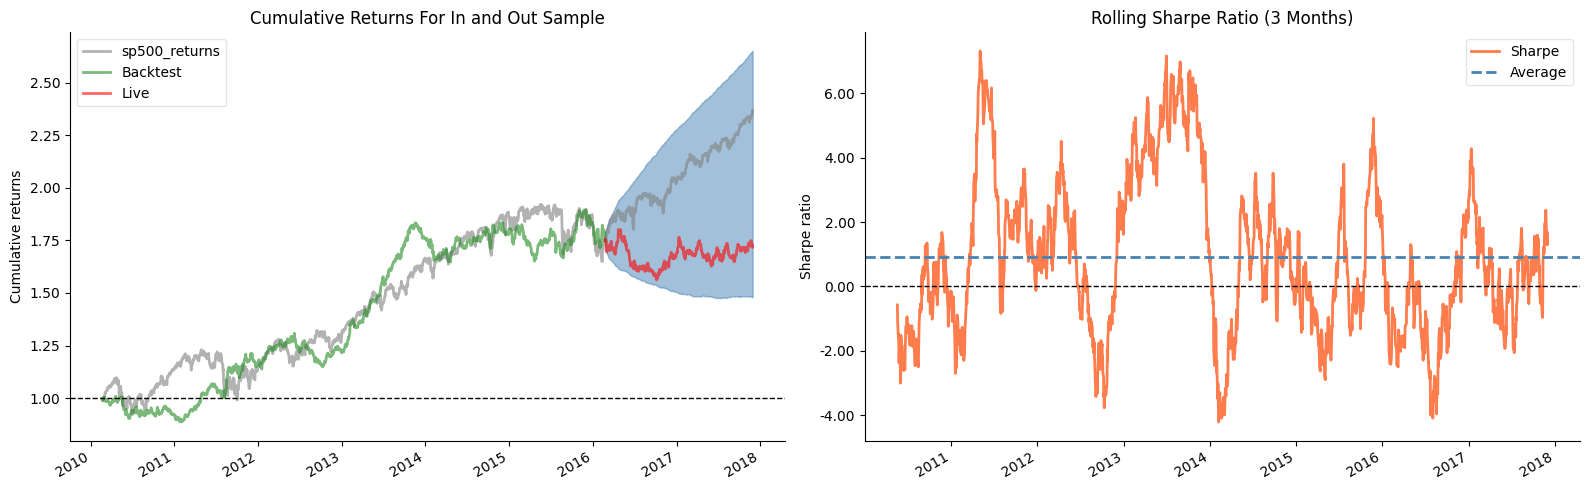

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,17.67,2015-12-03,2016-10-06,NaT,NaN
1,12.10,2012-06-08,2012-10-09,2013-02-05,173
2,12.04,2010-04-21,2011-01-26,2011-04-29,268
3,10.10,2013-11-18,2014-04-21,2014-12-03,273
4,10.00,2014-12-03,2015-04-22,2015-10-26,234


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.55%,-2.04%,3.37%
Fukushima,0.11%,-0.90%,0.73%
EZB IR Event,-0.12%,-1.58%,0.89%
Flash Crash,0.20%,0.09%,0.25%
Apr14,0.05%,-1.28%,1.36%
Oct14,-0.01%,-1.34%,2.03%
Fall2015,0.09%,-1.25%,2.28%
Recovery,0.03%,-3.20%,3.37%
New Normal,0.03%,-2.86%,2.82%


Top 10 long positions of all time,max
sid,
NFLX,39.14%
PCG,24.63%
URI,22.09%
BLDR,20.81%
VRTX,20.71%
AOS,20.40%
MDT,20.39%
MSI,20.01%
GE,19.96%


Top 10 short positions of all time,max
sid,
NFLX,-45.44%
URI,-27.55%
NRG,-24.07%
MSI,-20.64%
EA,-20.23%
DGX,-19.81%
VMC,-19.79%
AMD,-19.76%
PCG,-19.75%


Top 10 positions of all time,max
sid,
NFLX,45.44%
URI,27.55%
PCG,24.63%
NRG,24.07%
BLDR,20.81%
VRTX,20.71%
MSI,20.64%
AOS,20.40%
MDT,20.39%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1079919.65,$-938143.53,$2018063.18
Gross profit,$29379111.86,$13528367.20,$15850744.66
Gross loss,$-28299192.21,$-14466510.72,$-13832681.49
Profit factor,$1.04,$0.94,$1.15
Avg. trade net profit,$14.27,$-25.50,$51.86
Avg. winning trade,$777.43,$765.53,$787.89
Avg. losing trade,$-759.24,$-768.72,$-749.58
Ratio Avg. Win:Avg. Loss,$1.02,$1.00,$1.05
Largest winning trade,$44453.76,$44196.87,$44453.76
Largest losing trade,$-42813.69,$-22267.92,$-42813.69


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:45:55.187286993,1 days 13:38:31.839312894,1 days 15:49:38.442456951
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,265 days 23:00:00,265 days 23:00:00,153 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.06%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,3.28%,2.66%,3.28%
Largest losing trade,-2.67%,-1.26%,-2.67%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.02%,0.00%,0.01%,-0.00%,-0.02%,-0.02%,-0.01%,0.00%,0.00%,-0.00%,0.02%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.02%,0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.02%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.07%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.00%,-0.02%,0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.01%,-0.02%,-0.03%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.02%,0.01%,-0.01%,-0.00%,0.00%,-0.02%,0.01%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.00%,0.00%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.01%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.01%,-0.01%,0.00%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.01%,0.01%,0.01%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.04%,-0.00%,0.01%,-0.00%,-0.02%,-0.01%,-0.01%,0.00%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,-0.00%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.01%,-0.01%,-0.01%,0.01%,0.00%,-0.00%,-0.02%,-0.00%,0.01%,0.01%,-0.01%,0.01%,0.00%,0.00%,0.01%,-0.00%,-0.01%,0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,0.00%,0.01%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.02%,-0.00%,0.01%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%
Avg returns winning,0.07%,0.03%,0.05%,0.

Profitability (PnL / PnL total) per name,
symbol,
NFLX,13.64%
DUK,12.11%
BBY,7.11%
BLDR,5.72%
MNST,5.53%
PWR,5.35%
JBL,5.21%
TAP,4.91%
GIS,4.65%


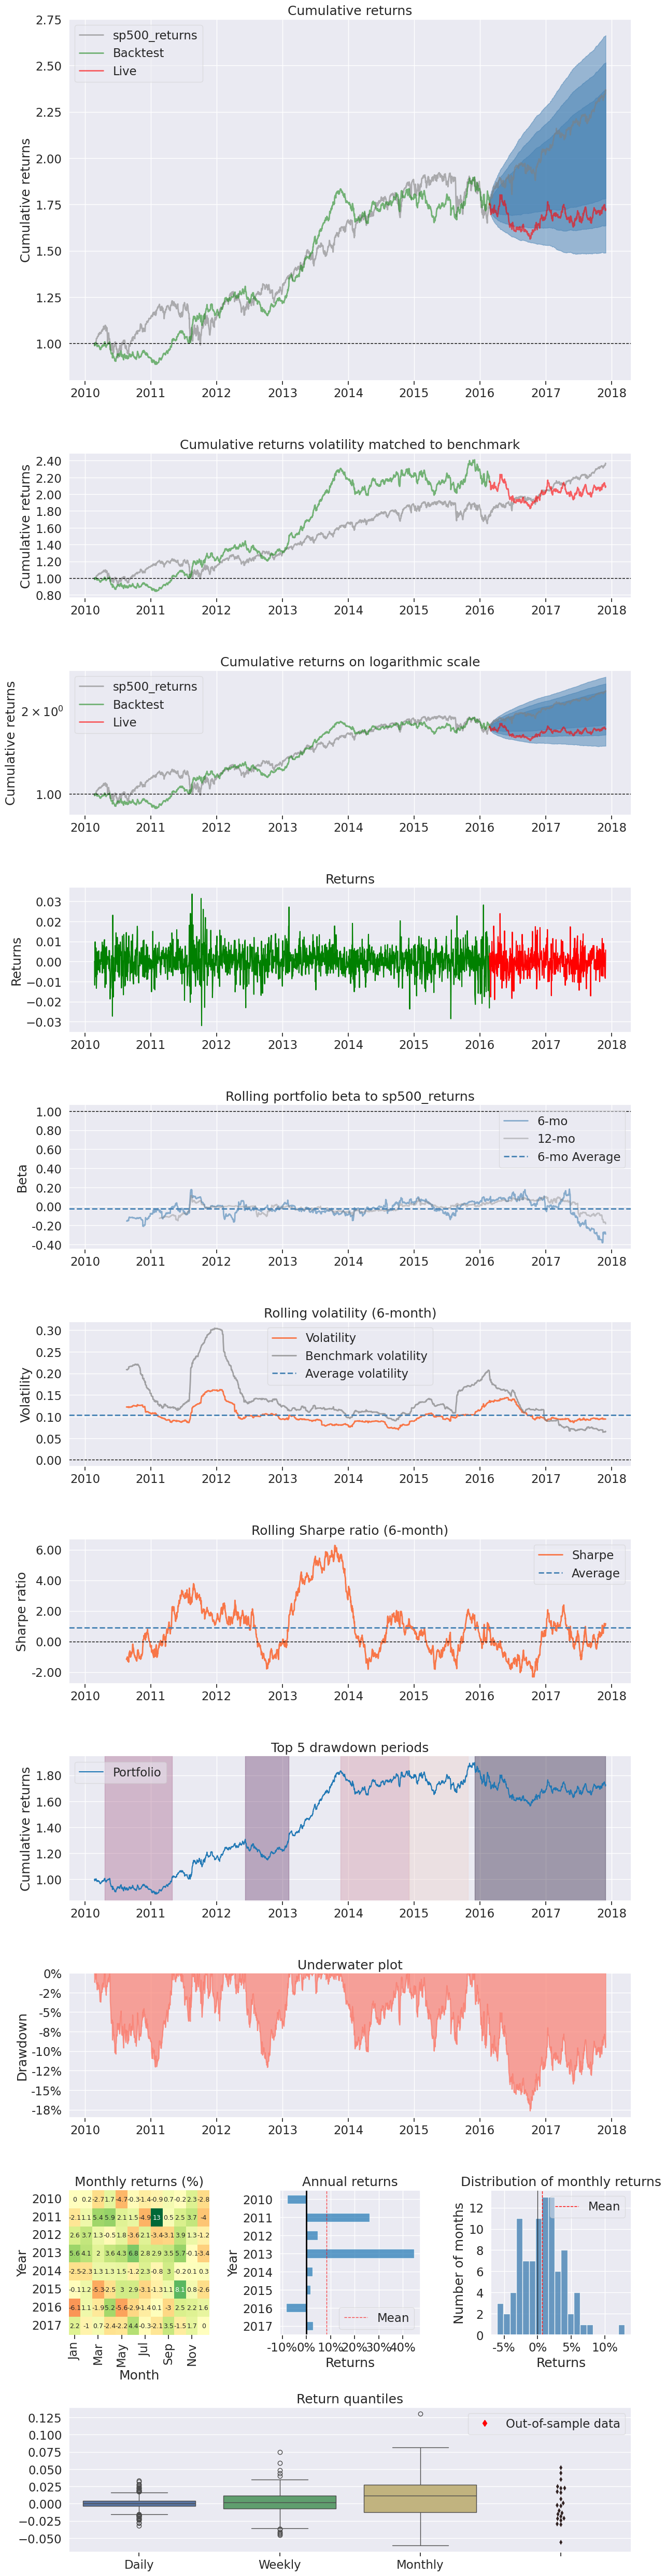

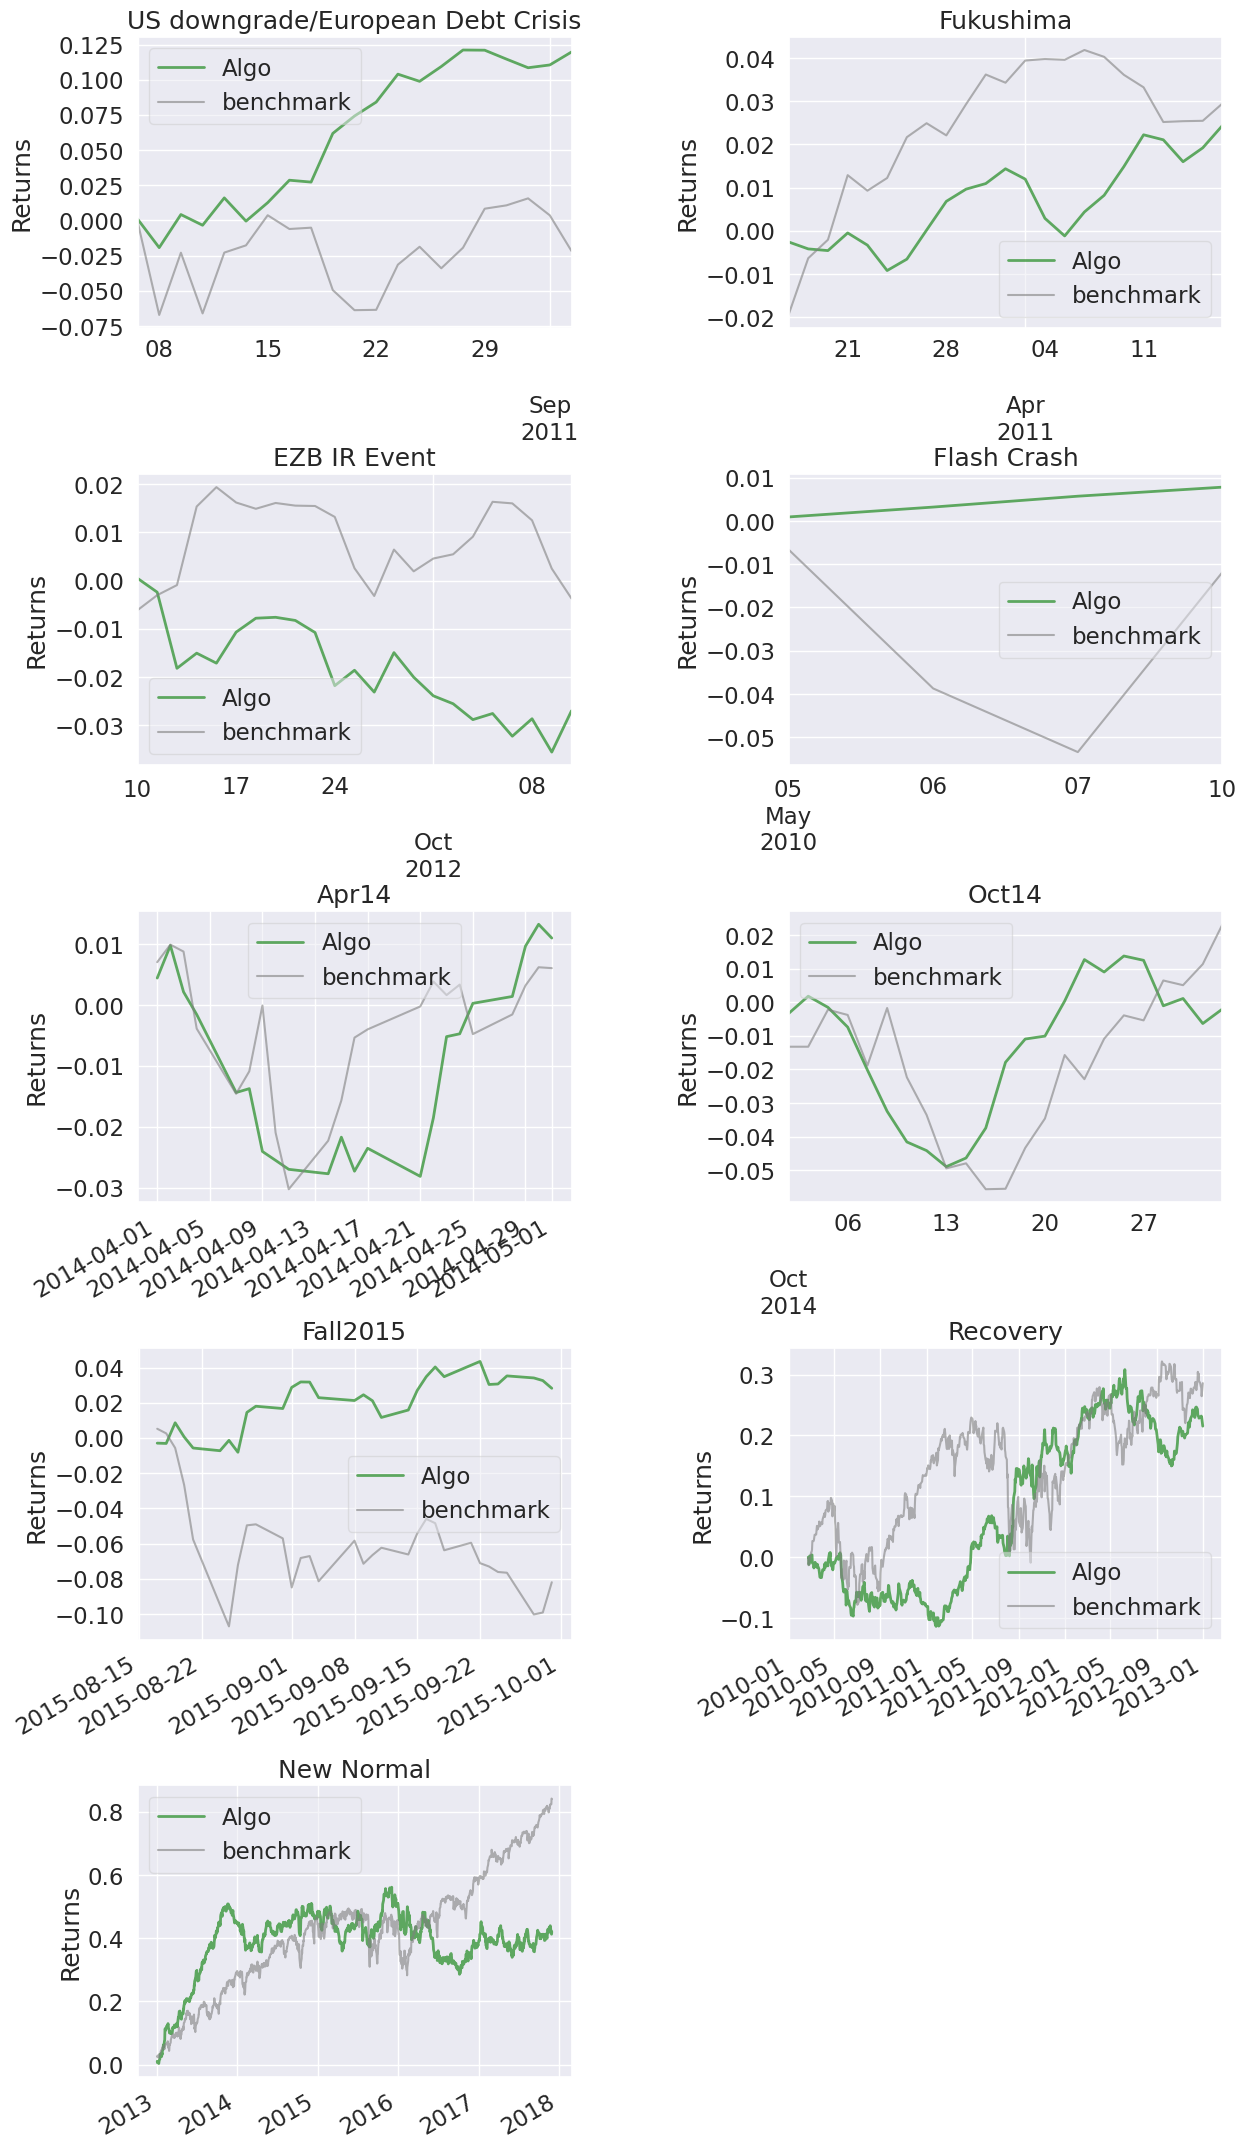

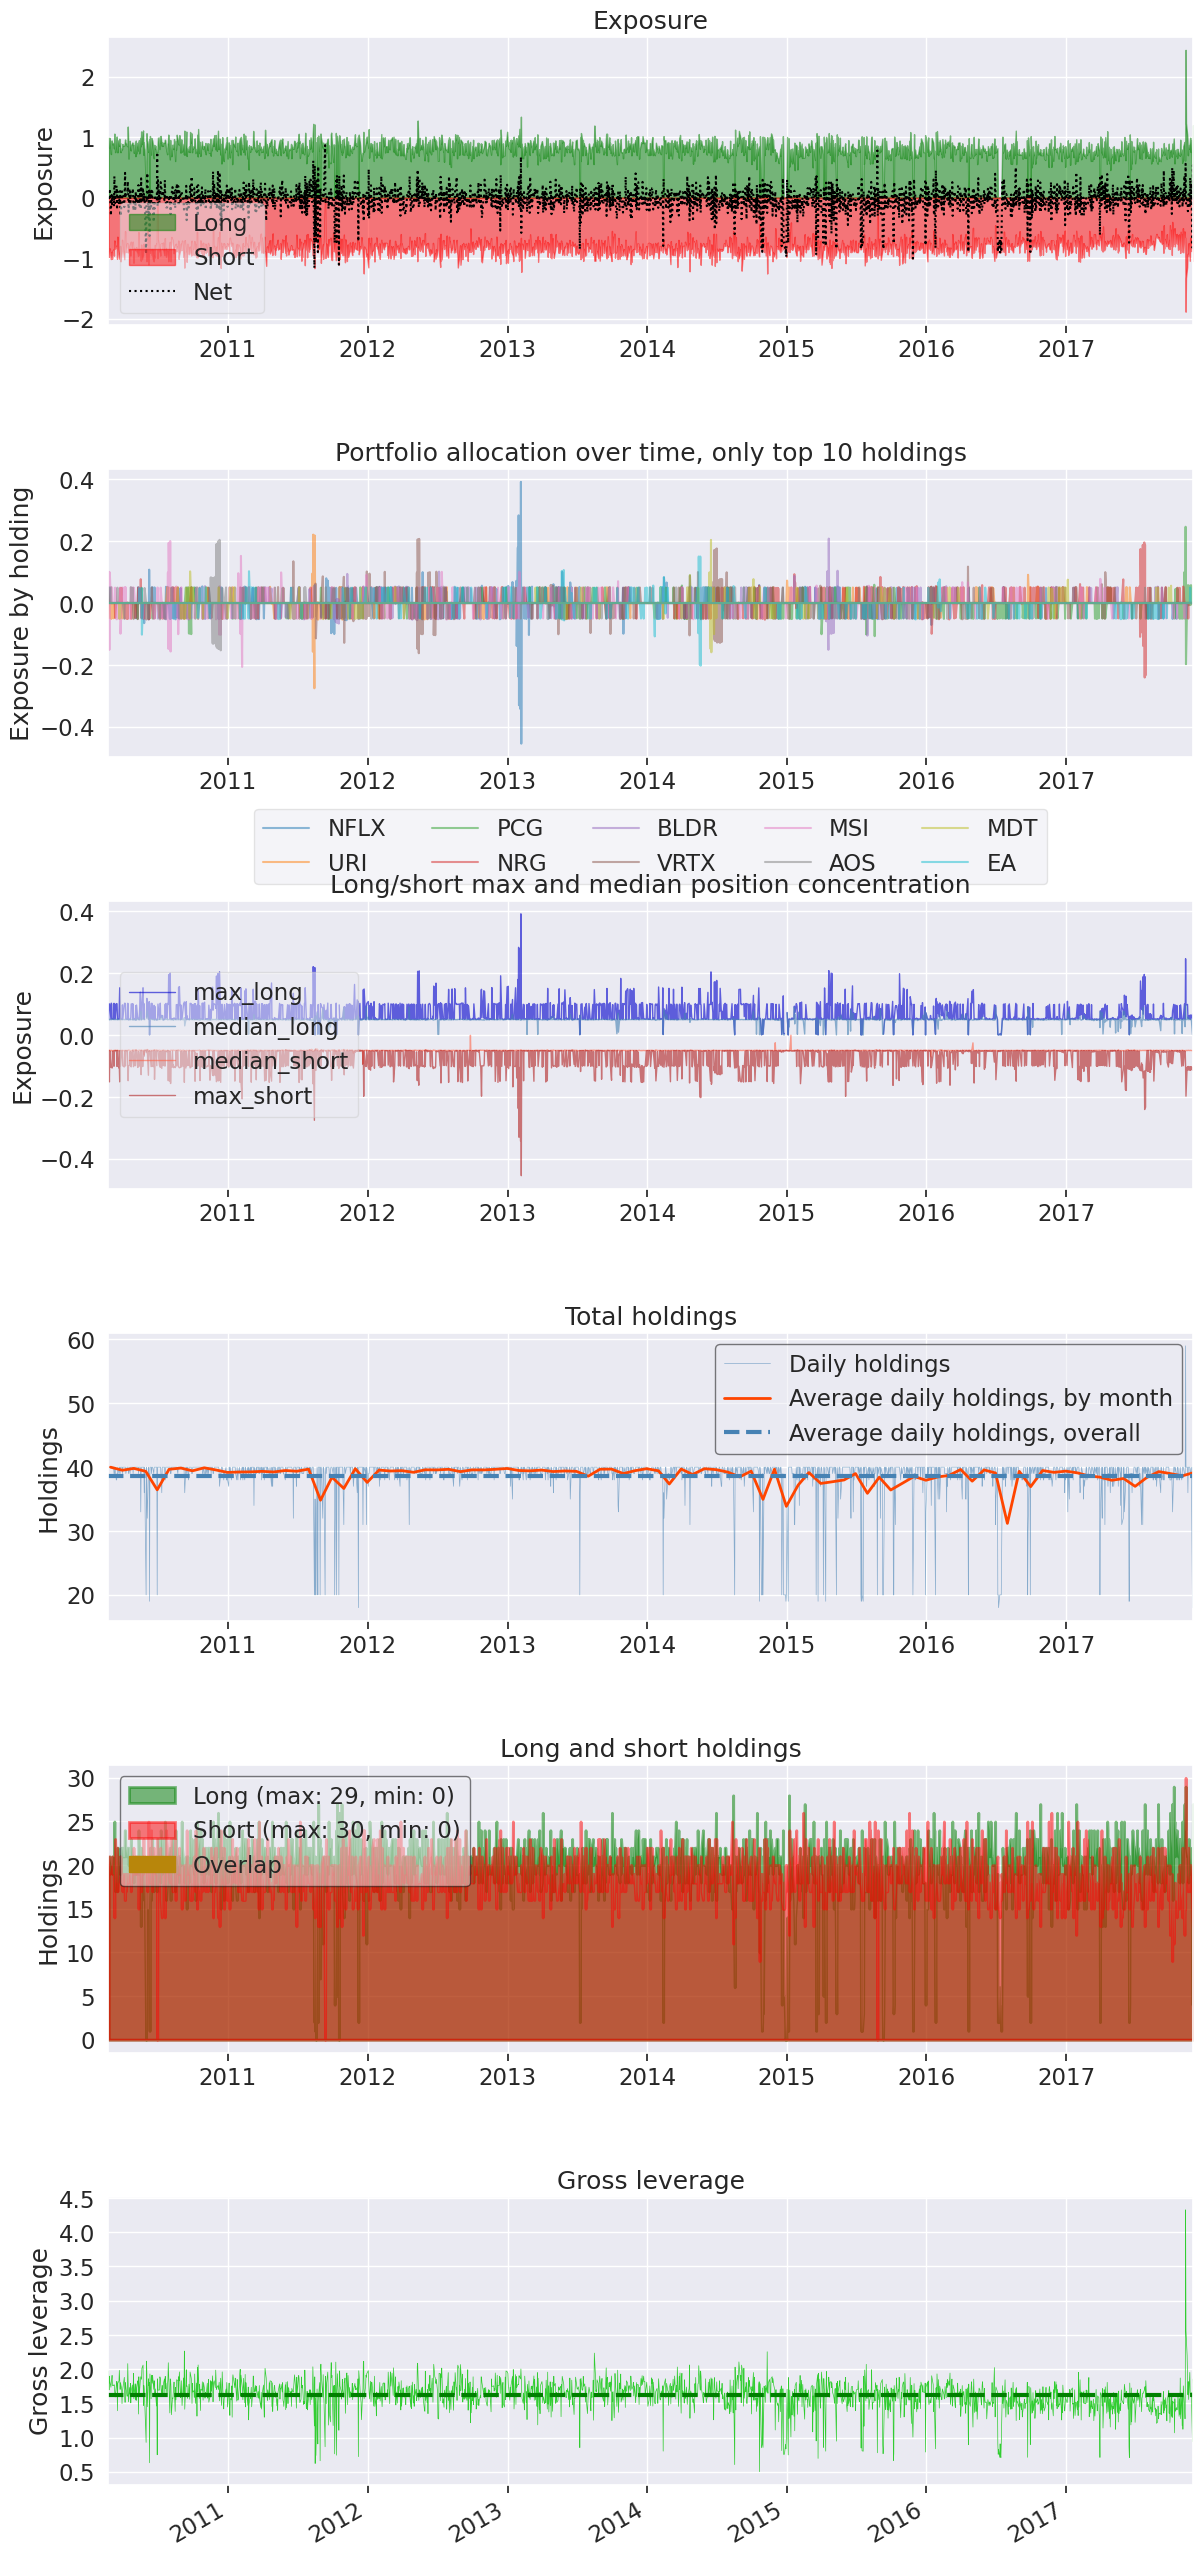

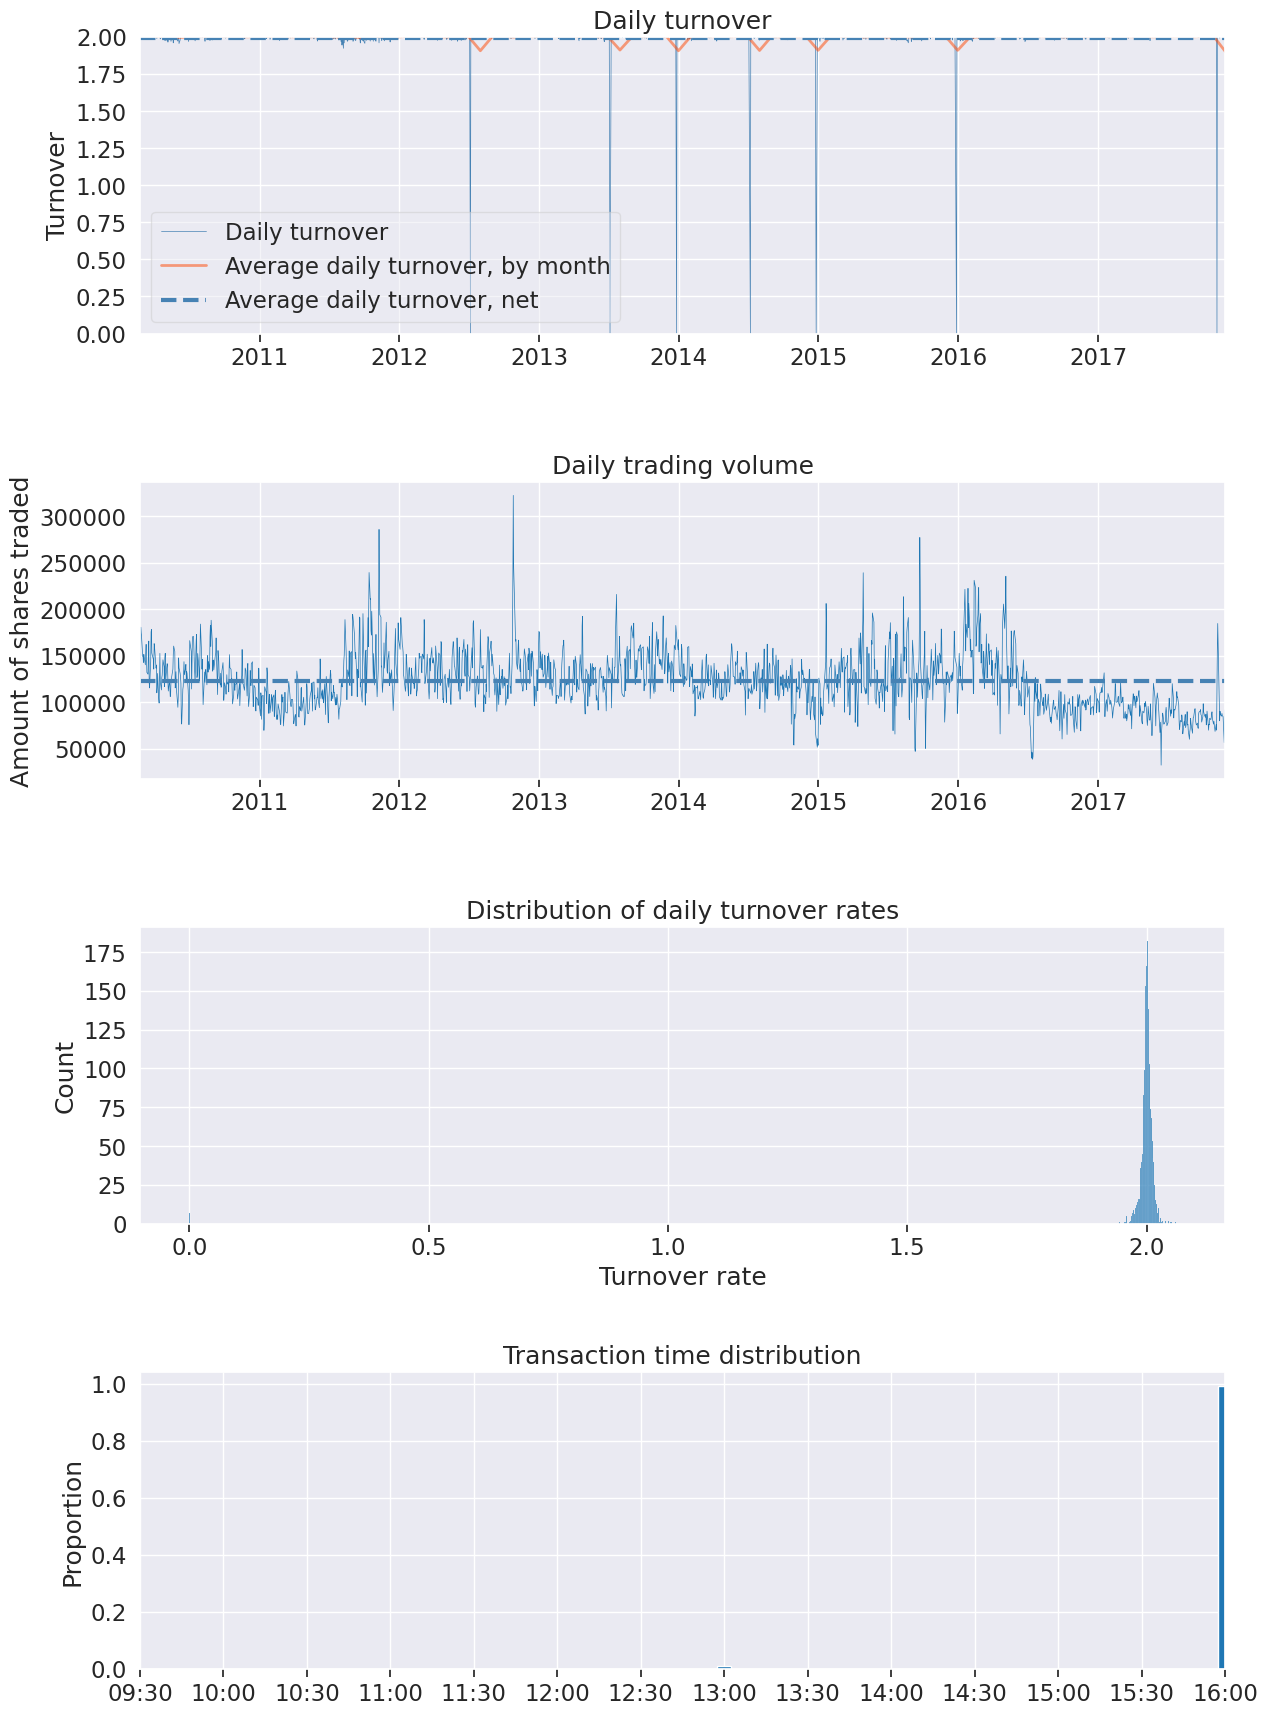

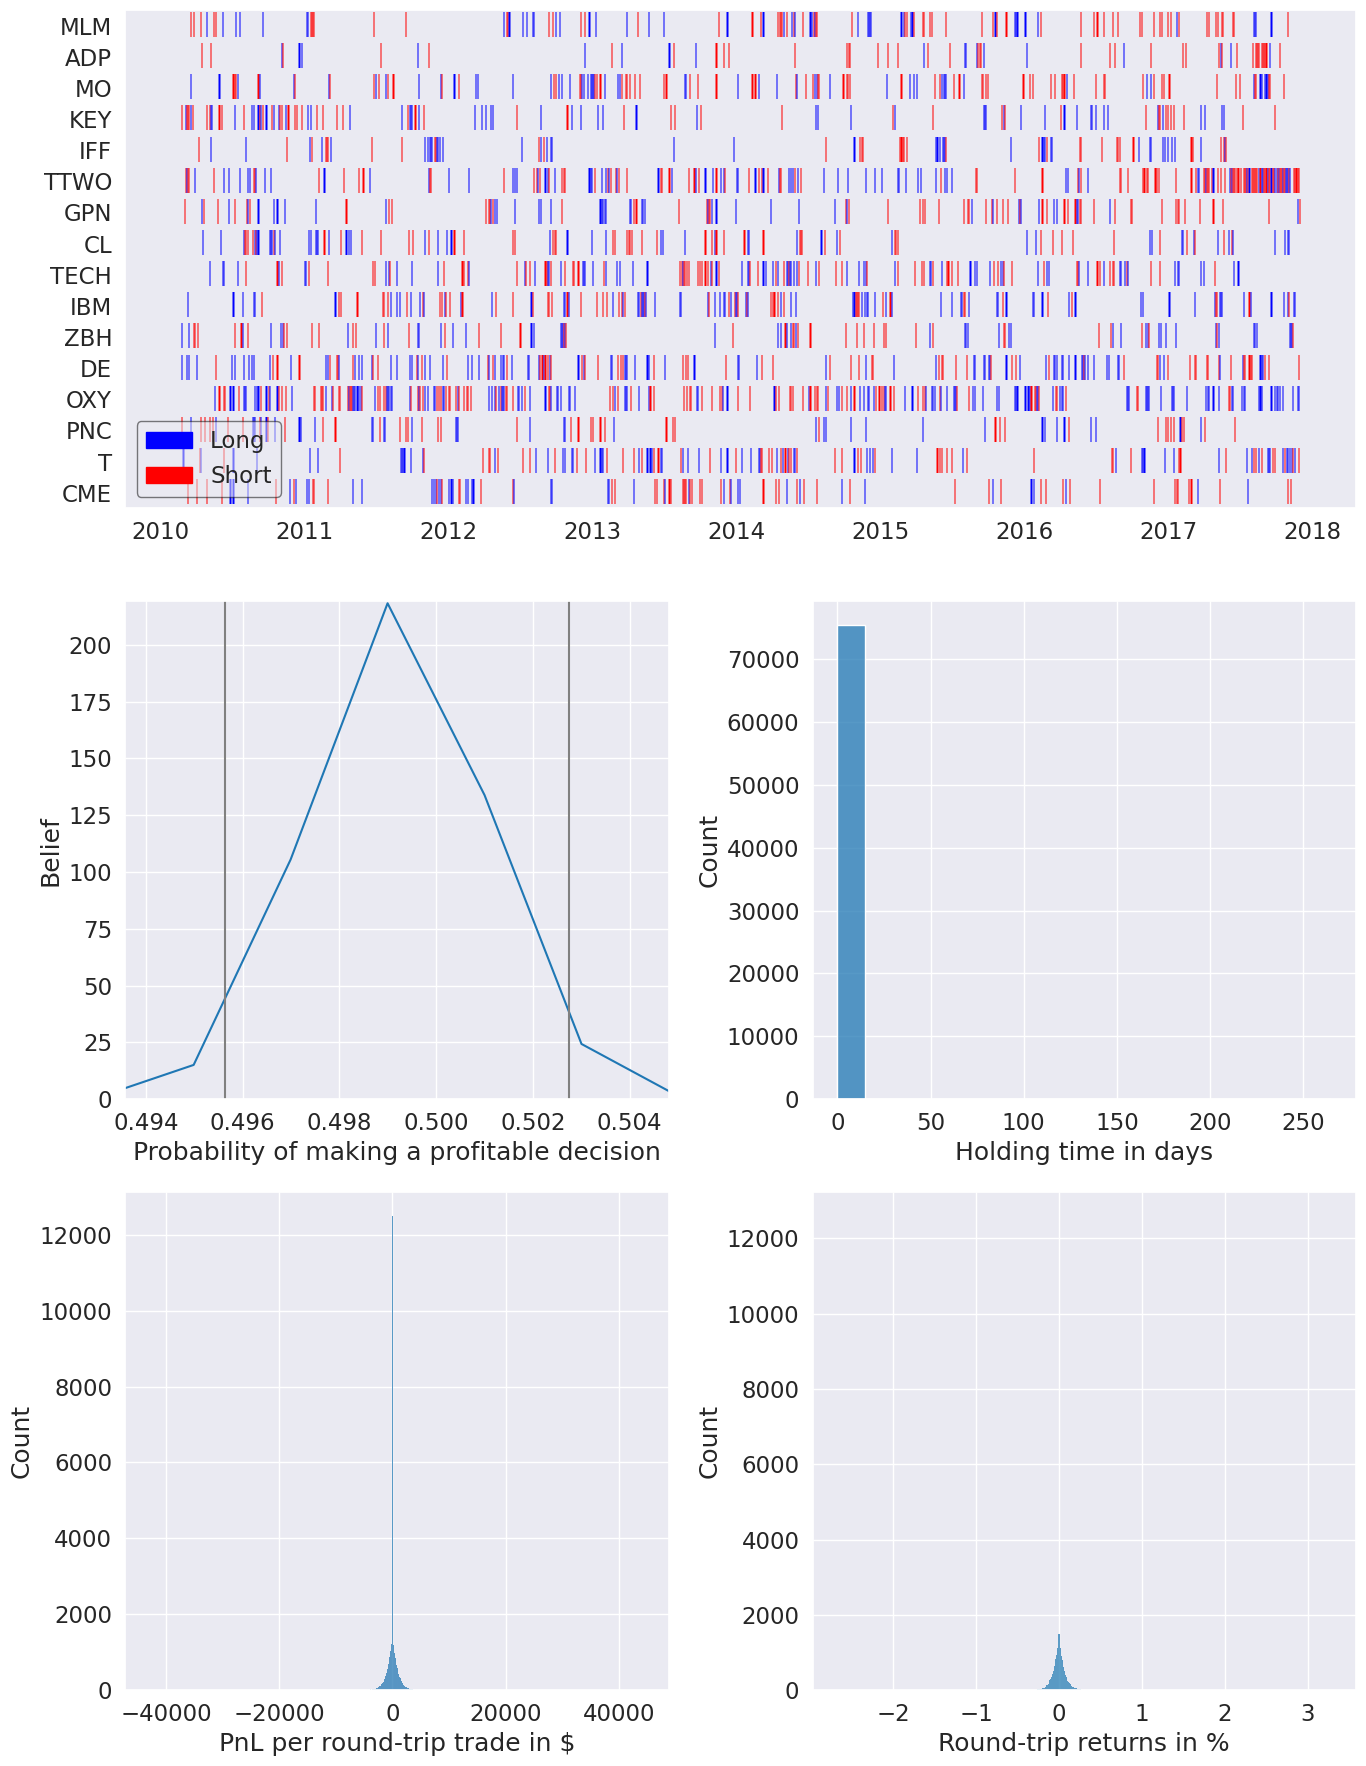

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-2 Factors, we will long and short predictions in quantiles 1 and 2 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":1,
        "quantile_short":2
}

}

In [17]:
backtester=BackTester(
    n_longs=50,
    n_shorts=50,
    min_positions=40,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model2_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

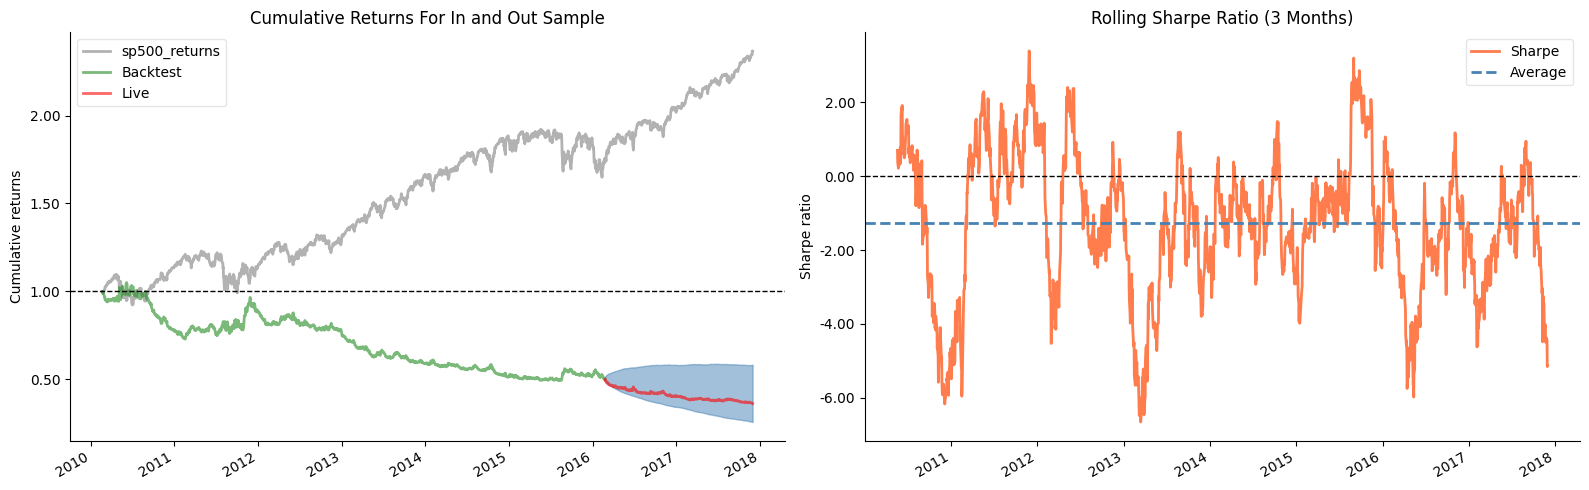

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout() 

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,65.57,2010-06-07,2017-11-29,NaT,NaN
1,6.74,2010-05-07,2010-05-12,2010-05-20,10
2,6.03,2010-02-22,2010-03-16,2010-05-06,54
3,4.74,2010-05-20,2010-06-02,2010-06-04,12
4,NaN,NaT,NaT,NaT,NaN


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.09%,-3.15%,4.53%
Fukushima,0.01%,-0.83%,1.27%
EZB IR Event,0.04%,-1.01%,1.30%
Flash Crash,0.29%,-4.54%,2.98%
Apr14,0.04%,-1.02%,1.72%
Oct14,-0.17%,-1.71%,1.74%
Fall2015,0.32%,-2.07%,3.68%
Recovery,-0.03%,-4.54%,4.94%
New Normal,-0.06%,-2.66%,3.68%


Top 10 long positions of all time,max
sid,
KEY,8.10%
SWKS,7.47%
MKTX,6.16%
MSI,6.01%
UNH,6.01%
ALL,6.00%
CF,5.99%
DGX,5.90%
IPG,5.90%


Top 10 short positions of all time,max
sid,
CNC,-6.54%
SJM,-6.52%
ROK,-6.51%
TEL,-6.49%
PLD,-6.49%
TTWO,-6.44%
MSCI,-6.42%
AES,-6.32%
NOC,-6.32%


Top 10 positions of all time,max
sid,
KEY,8.10%
SWKS,7.47%
CNC,6.54%
SJM,6.52%
ROK,6.51%
TEL,6.49%
PLD,6.49%
TTWO,6.44%
MSCI,6.42%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-514773.22,$-653359.79,$138586.57
Gross profit,$7055485.05,$5854684.94,$1200800.11
Gross loss,$-7570258.27,$-6508044.73,$-1062213.54
Profit factor,$0.93,$0.90,$1.13
Avg. trade net profit,$-5.18,$-7.62,$10.18
Avg. winning trade,$149.02,$145.40,$169.63
Avg. losing trade,$-148.08,$-145.46,$-166.47
Ratio Avg. Win:Avg. Loss,$1.01,$1.00,$1.02
Largest winning trade,$11736.47,$11736.47,$5310.19
Largest losing trade,$-10905.16,$-3472.70,$-10905.16


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 17:00:11.599941595,1 days 13:44:40.183451768,2 days 13:31:39.607922392
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,126 days 01:00:00,126 days 01:00:00,124 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.02%,0.02%,0.02%
Avg returns losing,-0.02%,-0.02%,-0.02%
Median returns all round_trips,-0.00%,-0.00%,0.00%
Median returns winning,0.01%,0.01%,0.01%
Median returns losing,-0.01%,-0.01%,-0.01%
Largest winning trade,3.23%,3.23%,1.46%
Largest losing trade,-1.96%,-0.47%,-1.96%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.00%,0.02%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0

Profitability (PnL / PnL total) per name,
symbol,
EW,3.77%
MKTX,2.27%
PFG,2.21%
ALGN,2.19%
MU,2.18%
STLD,2.13%
ARE,2.07%
VLO,2.04%
VRSN,1.95%


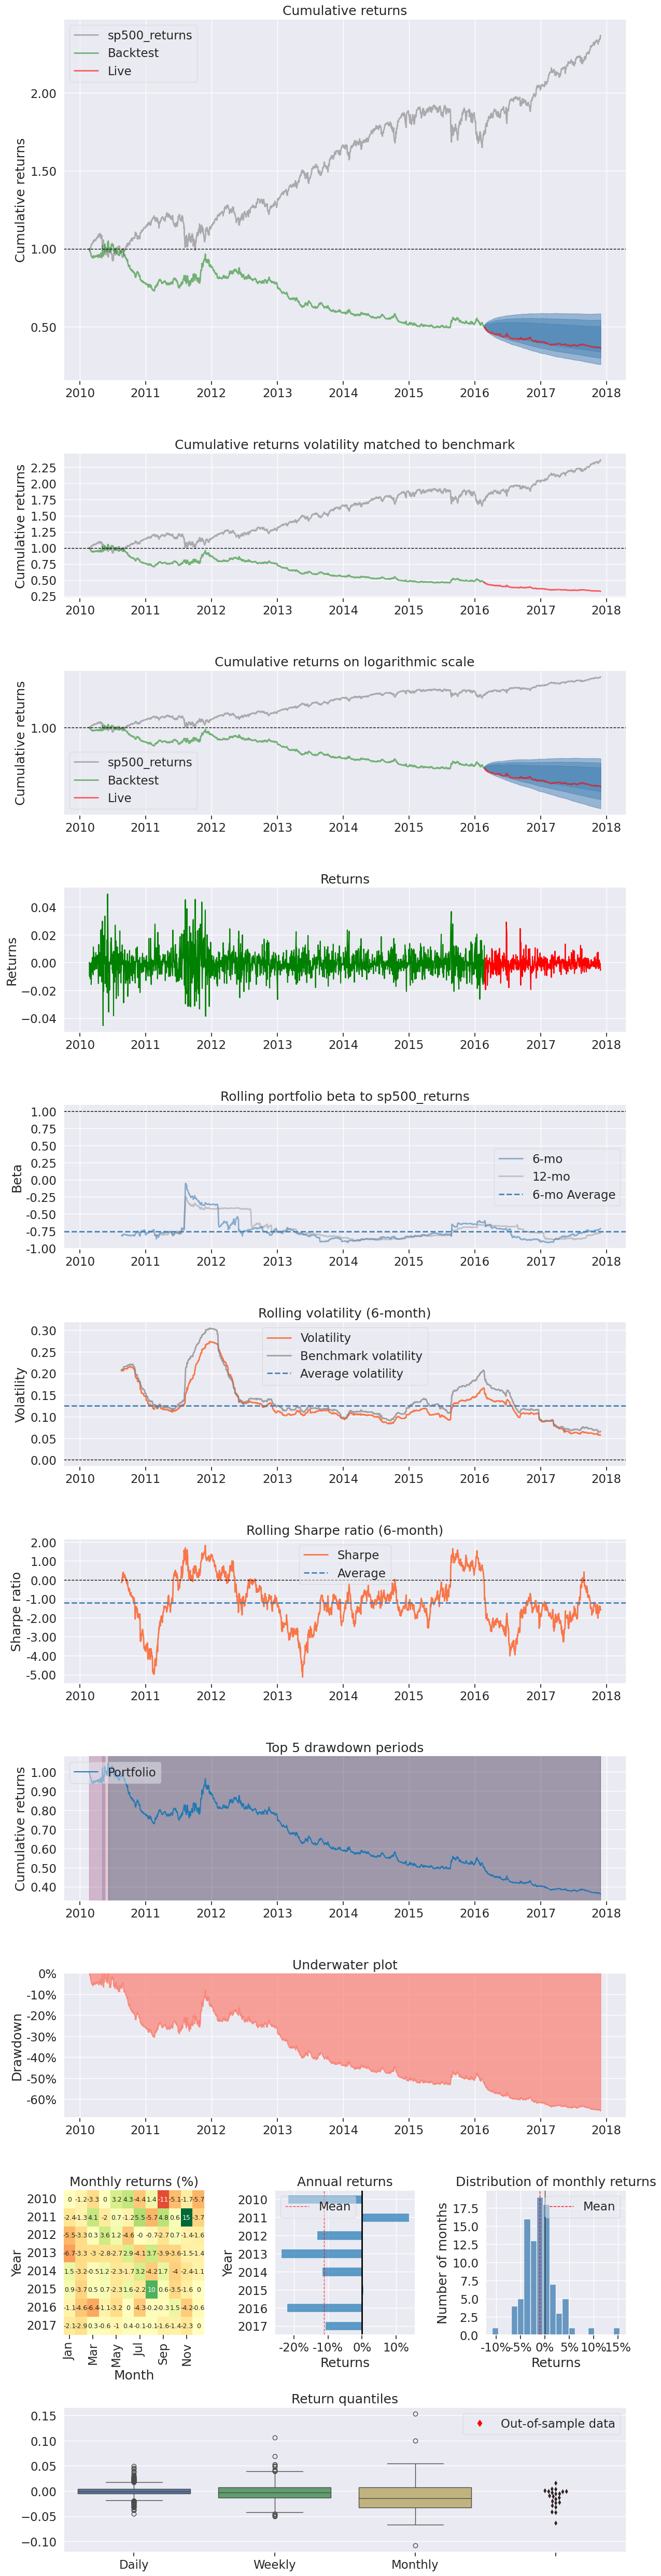

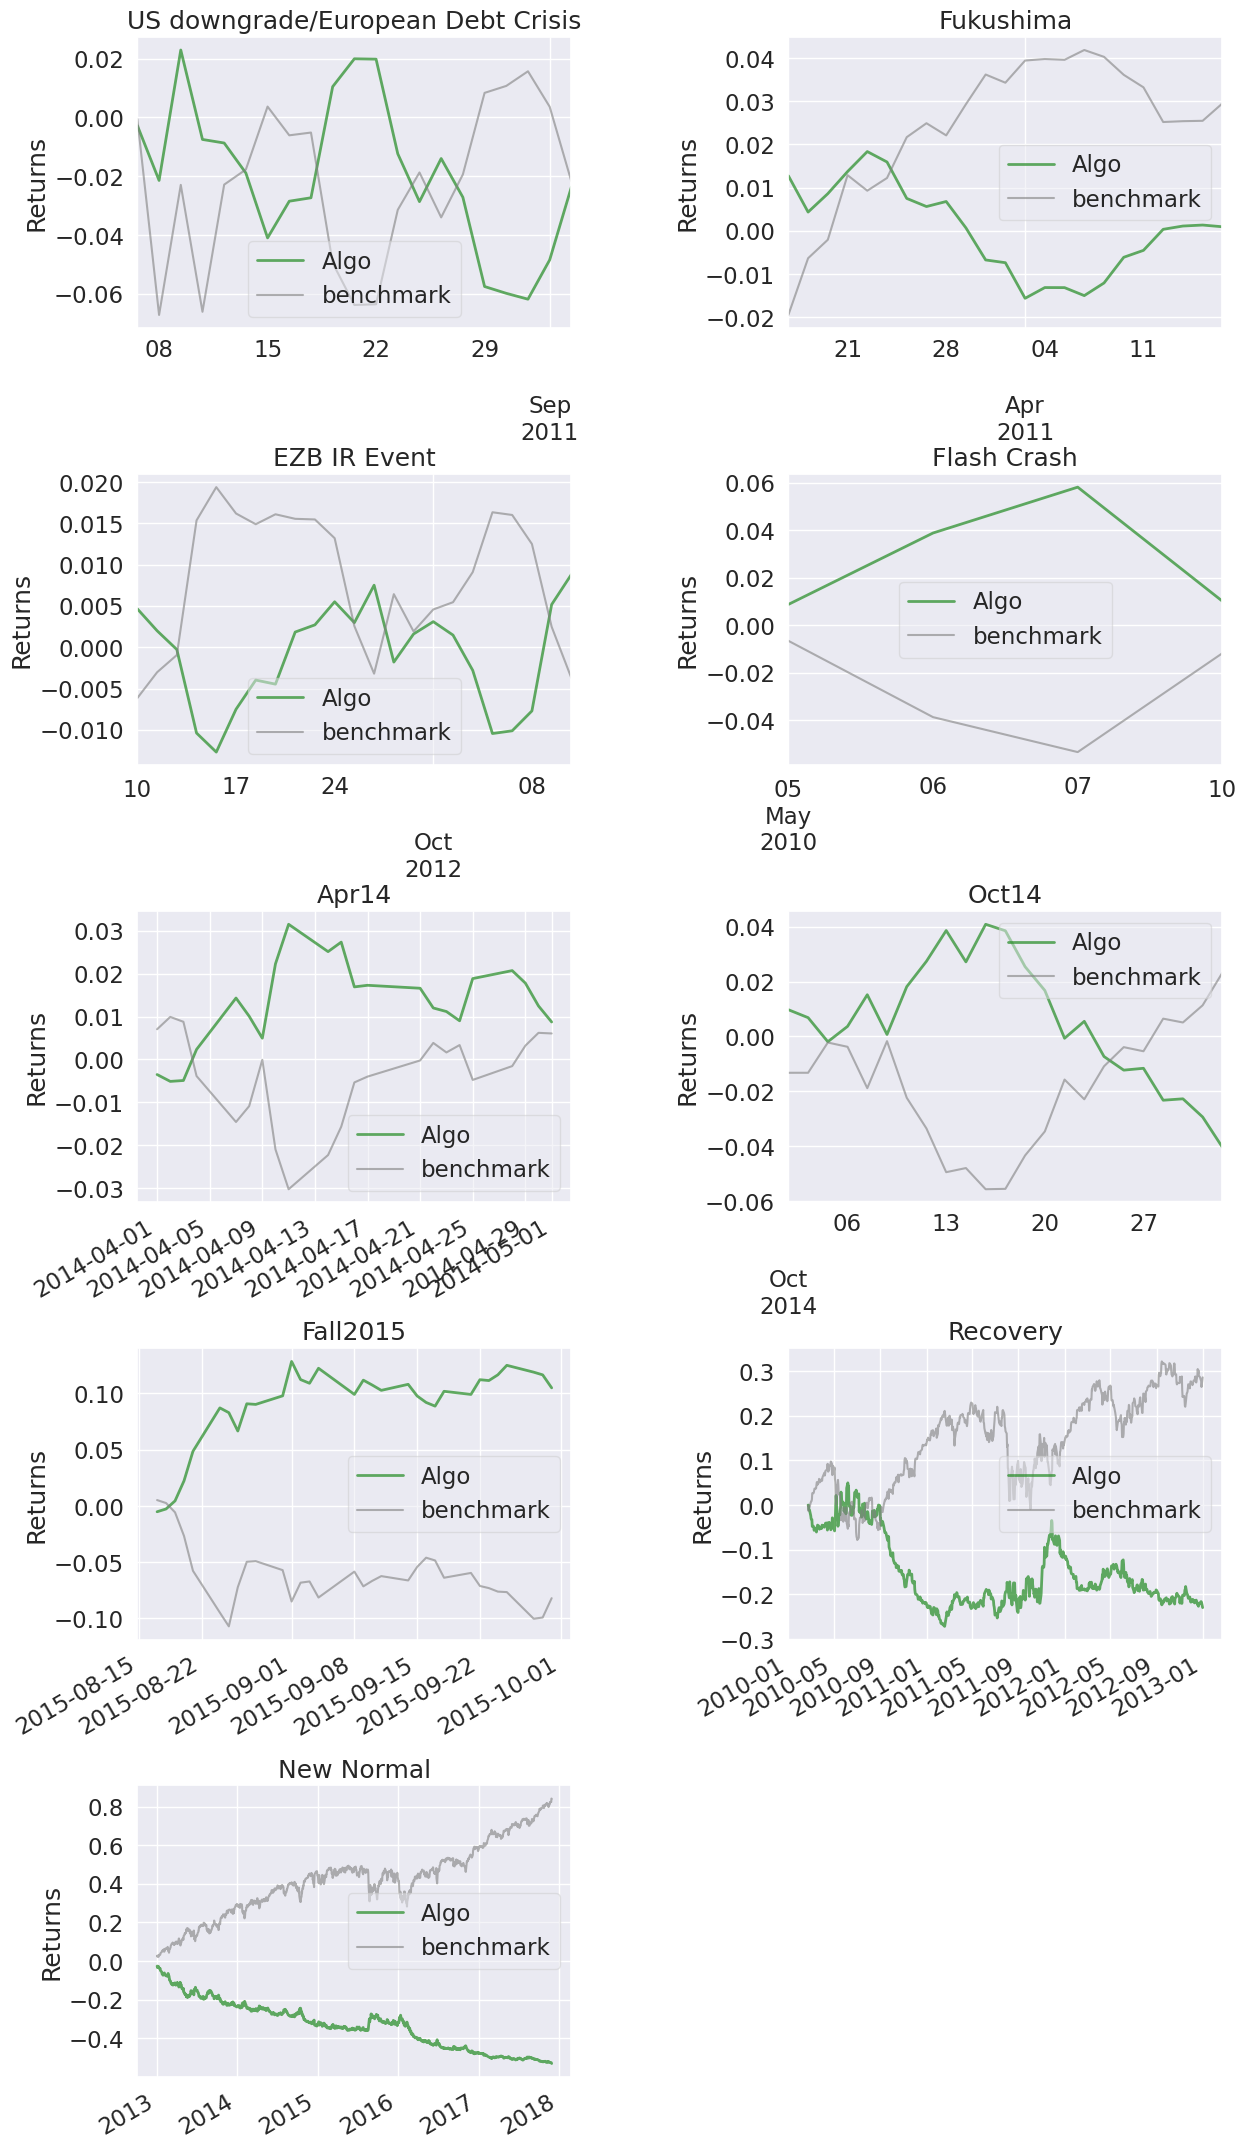

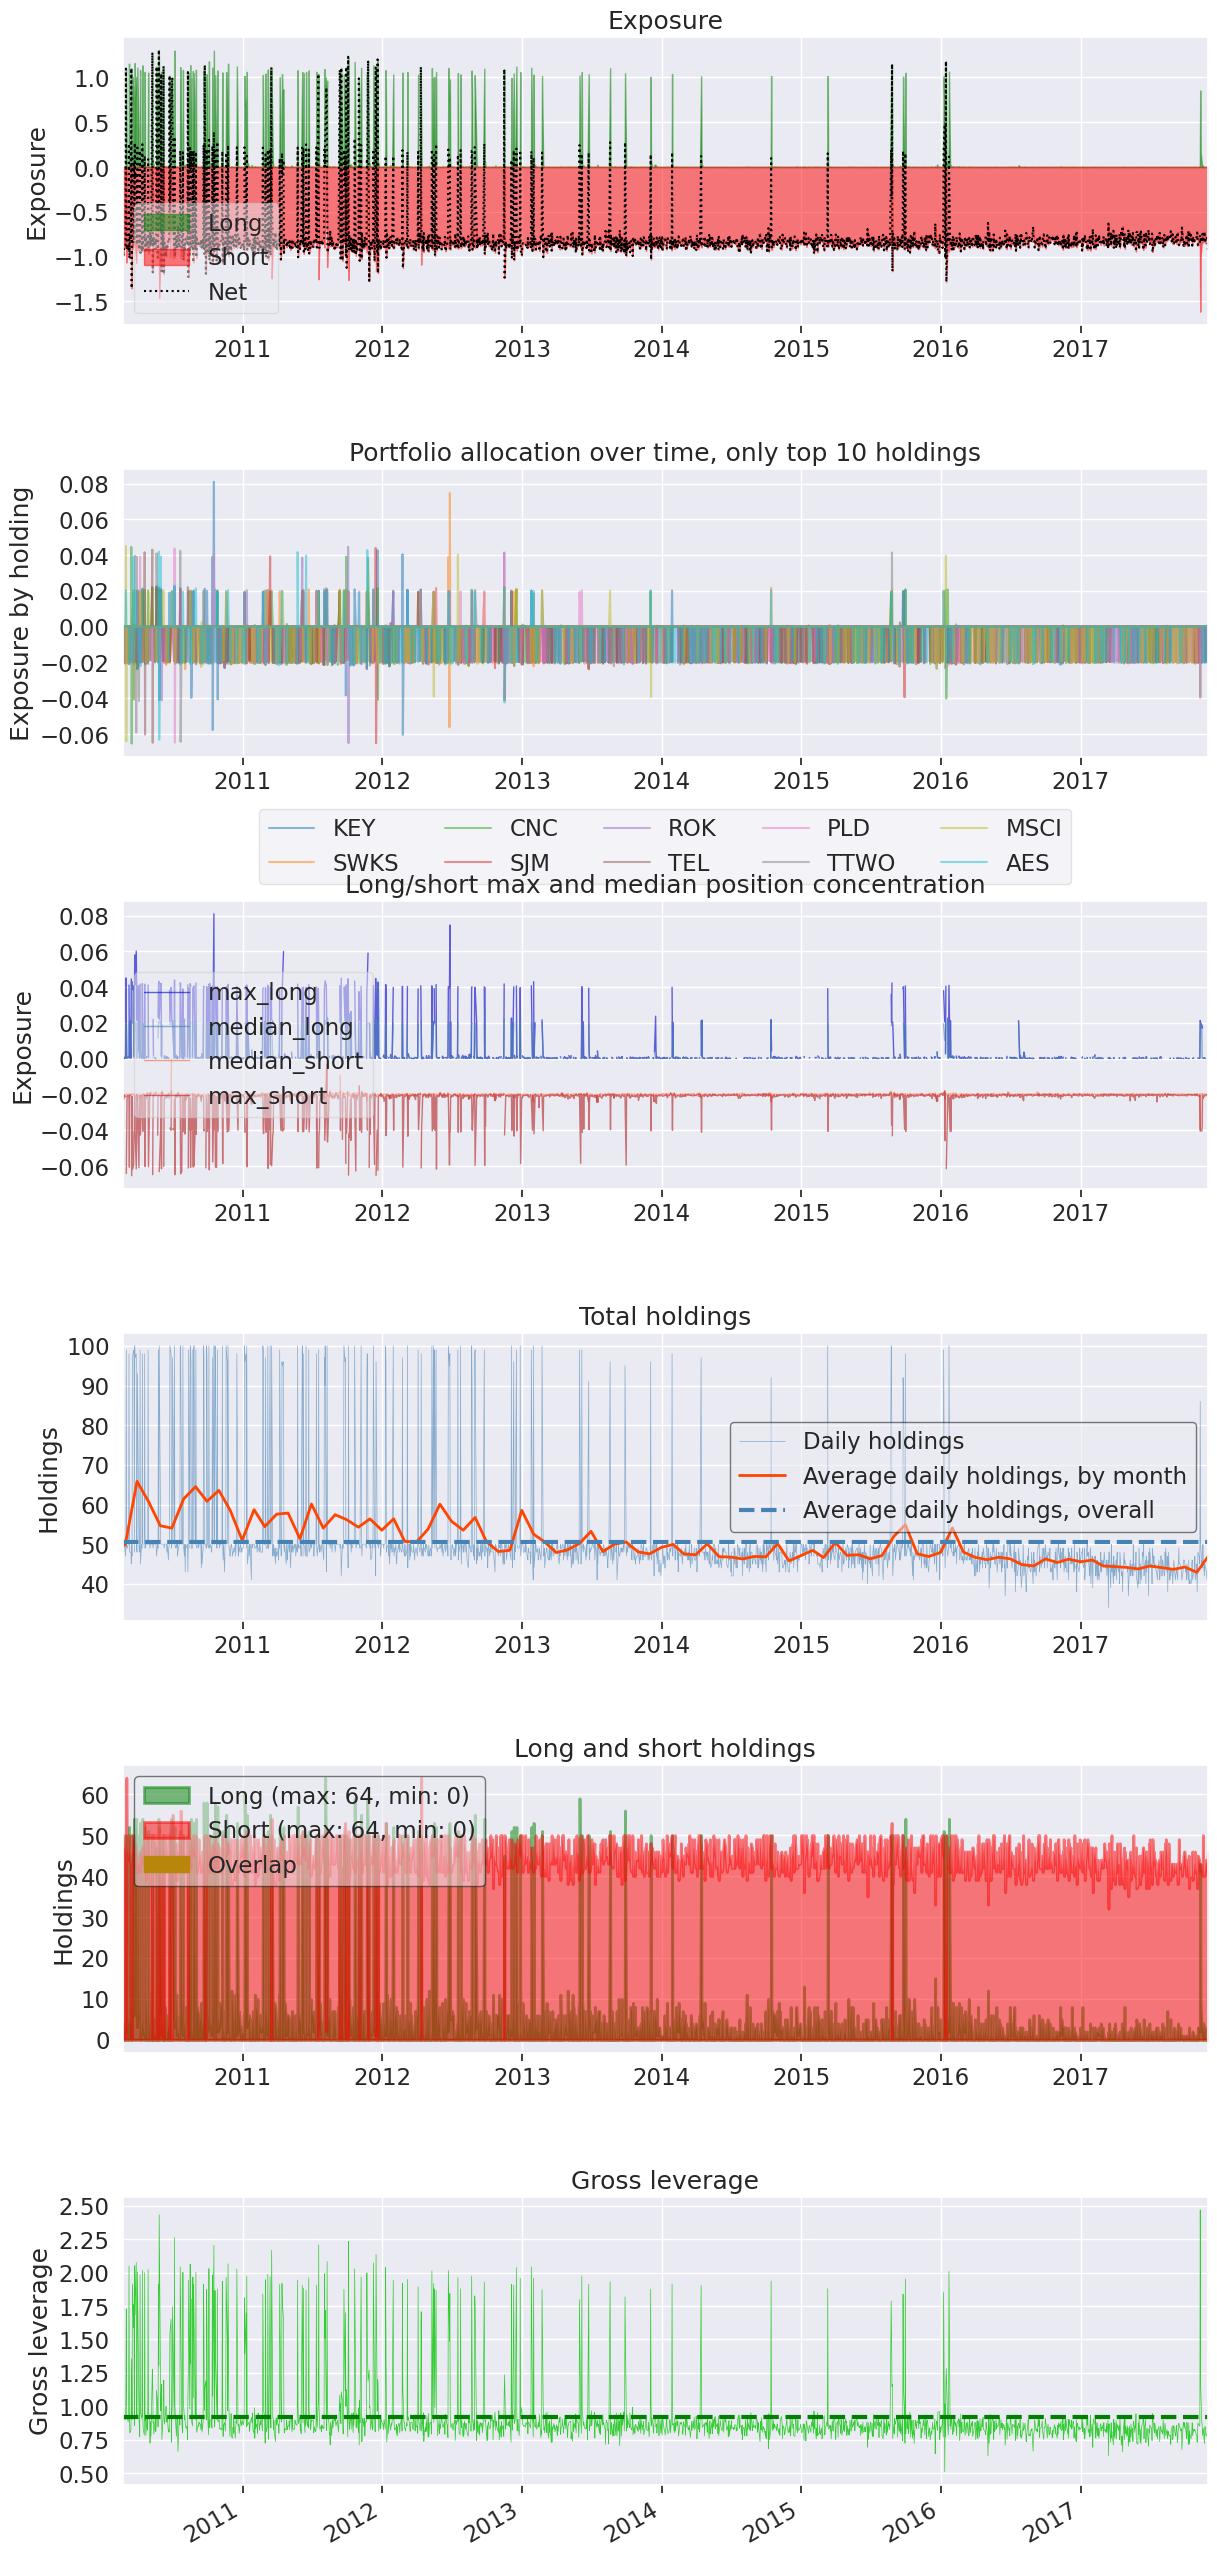

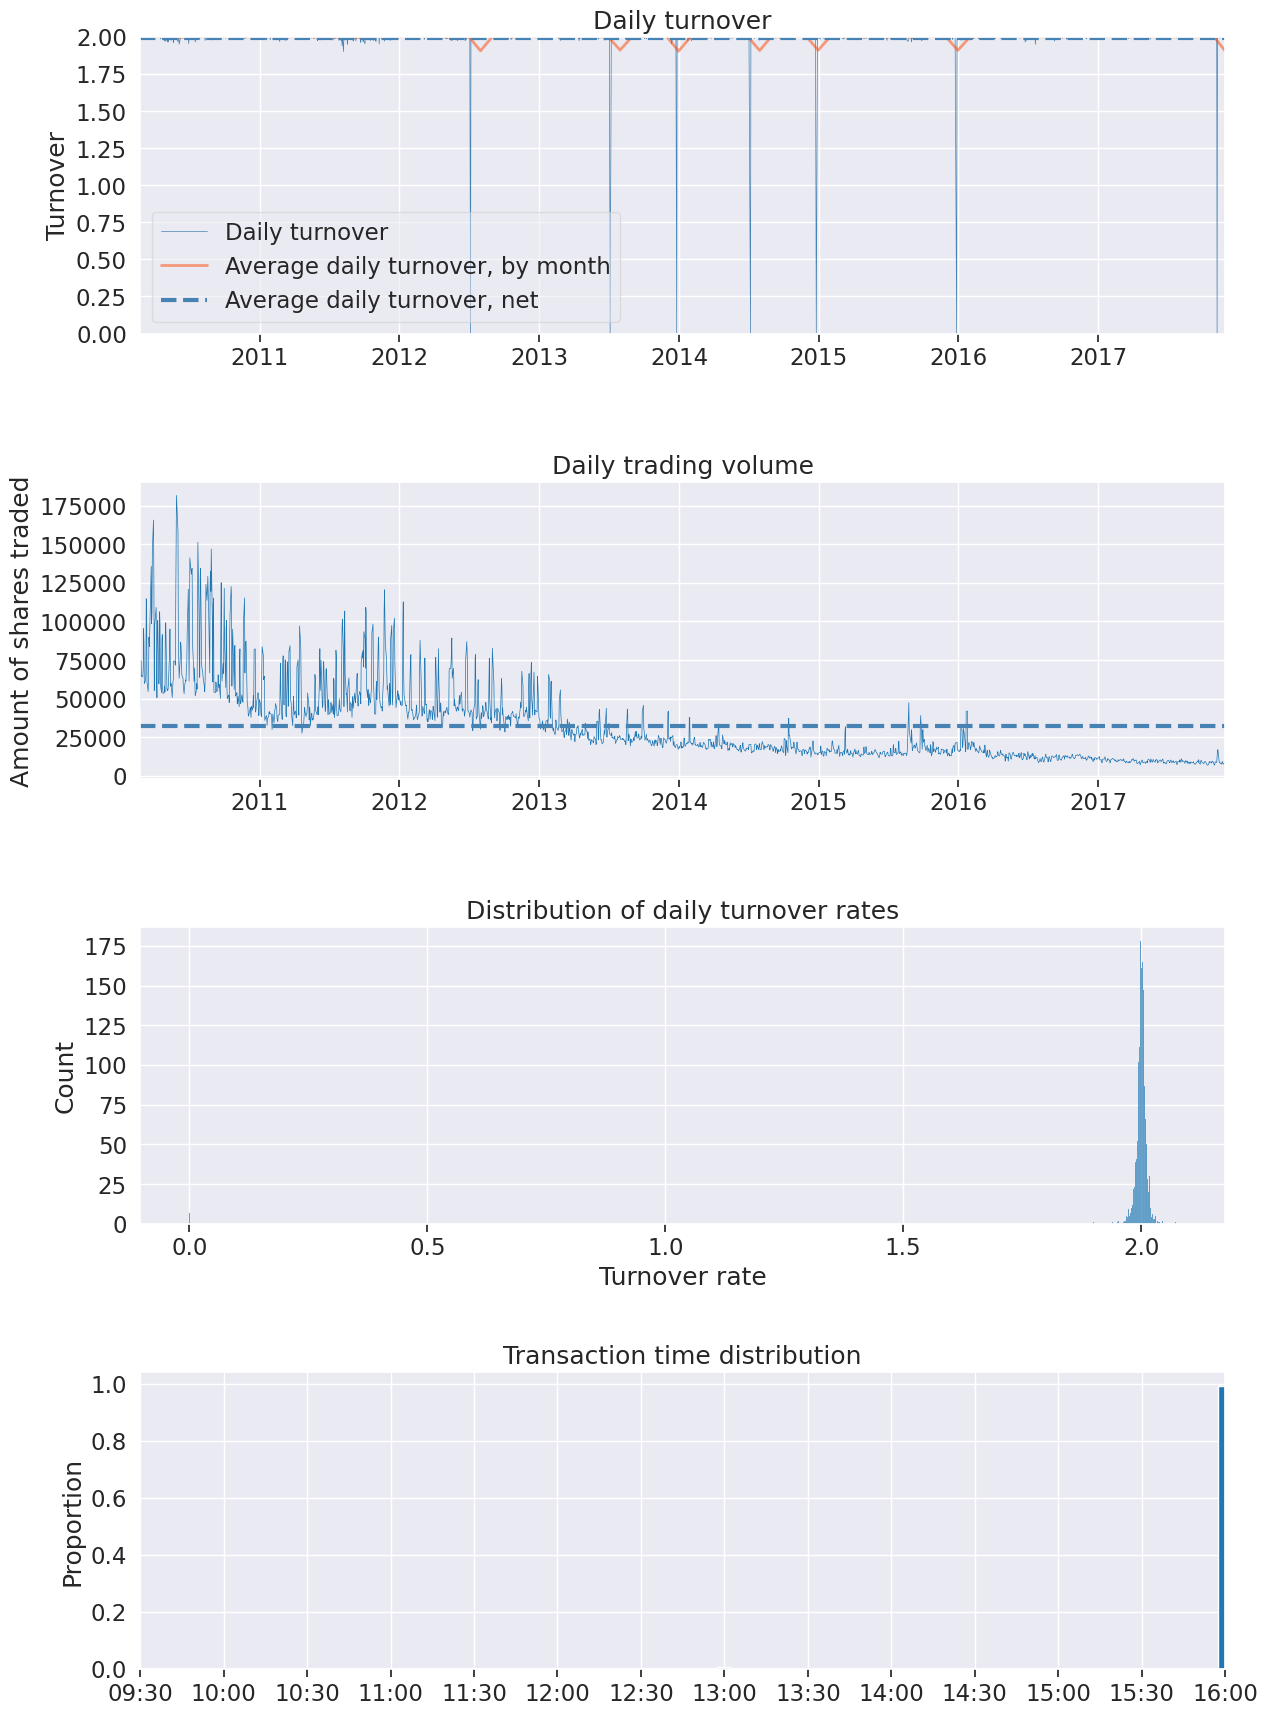

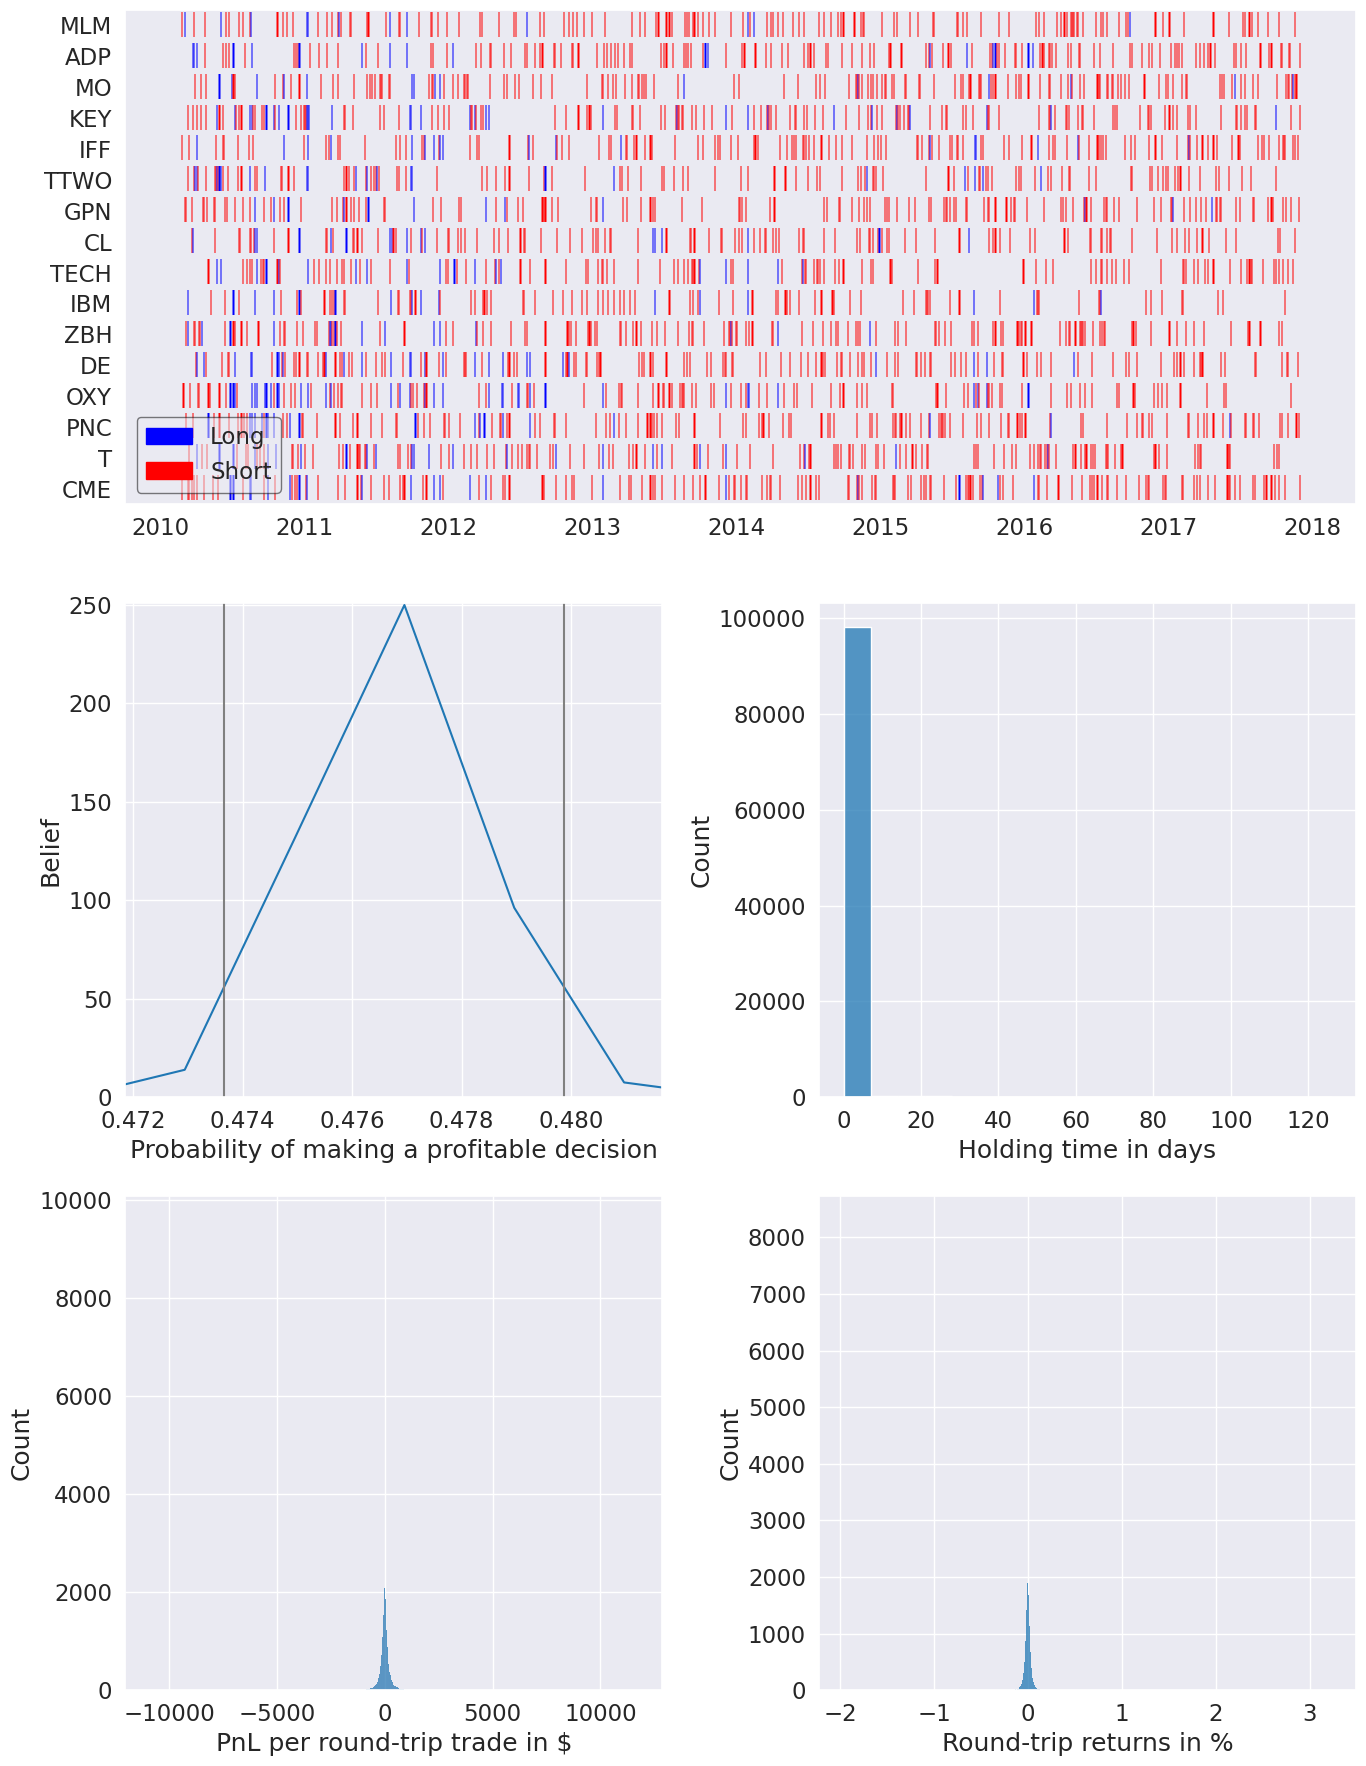

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)